In [ ]:
!pip -q install gymnasium[classic-control] imageio matplotlib torch numpy


In [ ]:
import math, random, time
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import imageio.v2 as imageio

import gymnasium as gym

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [ ]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def moving_average(x, window=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return x
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[window:] - c[:-window]) / window

def make_env(seed=0, render_mode=None):
    env = gym.make("CartPole-v1", render_mode=render_mode)
    obs, info = env.reset(seed=seed)
    env.action_space.seed(seed)
    return env


In [ ]:
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return s, a, r.astype(np.float32), s2, d.astype(np.float32)

    def __len__(self):
        return len(self.buf)


In [ ]:
class QNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
@torch.no_grad()
def select_action(q_net, obs, eps, n_actions):
    if random.random() < eps:
        return random.randrange(n_actions)
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    q = q_net(obs_t)
    return int(torch.argmax(q, dim=1).item())


## Core: training step (DQN vs Double DQN)

### Key difference:

- DQN target: max_a Q_target(s', a)

- Double DQN target: Q_target(s', argmax_a Q_online(s', a))

In [ ]:
def train_step(
    q_online, q_target, optimizer, buffer,
    batch_size=64, gamma=0.99, double_dqn=False,
    grad_clip=10.0
):
    if len(buffer) < batch_size:
        return None

    s, a, r, s2, done = buffer.sample(batch_size)

    s_t  = torch.tensor(s,  dtype=torch.float32, device=DEVICE)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=DEVICE)
    r_t  = torch.tensor(r,  dtype=torch.float32, device=DEVICE)
    s2_t = torch.tensor(s2, dtype=torch.float32, device=DEVICE)
    d_t  = torch.tensor(done, dtype=torch.float32, device=DEVICE)

    q_sa = q_online(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        if not double_dqn:
            # DQN: action selection + evaluation both from target net
            max_next = q_target(s2_t).max(dim=1)[0]
        else:
            # Double DQN: selection from online, evaluation from target
            a_star = torch.argmax(q_online(s2_t), dim=1)
            max_next = q_target(s2_t).gather(1, a_star.unsqueeze(1)).squeeze(1)

        target = r_t + gamma * (1.0 - d_t) * max_next

    loss = nn.functional.mse_loss(q_sa, target)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    if grad_clip is not None:
        nn.utils.clip_grad_norm_(q_online.parameters(), grad_clip)
    optimizer.step()

    return float(loss.item())


- For DQN, selection and eval are same net ⇒ tends to be larger.

- For Double DQN, selection uses online and eval uses target ⇒ tends to be smaller.

In [ ]:
@torch.no_grad()
def bias_metrics(q_online, q_target, states_batch):
    s_t = torch.tensor(states_batch, dtype=torch.float32, device=DEVICE)
    q_on  = q_online(s_t)
    q_tgt = q_target(s_t)

    # A) average max-Q on online net
    mean_maxQ_online = float(q_on.max(dim=1)[0].mean().item())

    # B) approximate overestimation gap:
    # max over target minus target evaluated at online-argmax
    max_tgt = q_tgt.max(dim=1)[0]
    a_star = torch.argmax(q_on, dim=1)
    eval_tgt_on_astar = q_tgt.gather(1, a_star.unsqueeze(1)).squeeze(1)
    gap = float((max_tgt - eval_tgt_on_astar).mean().item())

    return mean_maxQ_online, gap


In [ ]:
def train_agent(
    algo_name="DQN",
    seed=0,
    total_steps=200_000,
    start_learning=2_000,
    batch_size=64,
    buffer_size=100_000,
    gamma=0.99,
    lr=1e-3,
    hidden=128,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=100_000,
    target_update_every=1_000,
    train_every=1,
    double_dqn=False
):
    set_seed(seed)
    env = make_env(seed=seed, render_mode=None)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    q_online = QNet(obs_dim, n_actions, hidden=hidden).to(DEVICE)
    q_target = QNet(obs_dim, n_actions, hidden=hidden).to(DEVICE)
    q_target.load_state_dict(q_online.state_dict())
    q_target.eval()

    optimizer = optim.Adam(q_online.parameters(), lr=lr)
    buffer = ReplayBuffer(capacity=buffer_size)

    # logs
    episode_returns = []
    episode_lengths = []
    losses = []
    eps_log = []

    # bias logs (sampled periodically)
    mean_maxQ_log = []
    gap_log = []
    step_log = []

    obs, info = env.reset()
    ep_return = 0.0
    ep_len = 0

    for step in range(1, total_steps + 1):
        # linear epsilon decay
        frac = min(1.0, step / max(1, eps_decay_steps))
        eps = eps_start + frac * (eps_end - eps_start)
        eps_log.append(eps)

        # act
        a = select_action(q_online, obs, eps, n_actions)
        obs2, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        buffer.push(obs, a, r, obs2, done)

        obs = obs2
        ep_return += r
        ep_len += 1

        # learn
        if step >= start_learning and step % train_every == 0:
            loss = train_step(
                q_online, q_target, optimizer, buffer,
                batch_size=batch_size, gamma=gamma, double_dqn=double_dqn
            )
            if loss is not None:
                losses.append(loss)

        # target update
        if step % target_update_every == 0:
            q_target.load_state_dict(q_online.state_dict())

        # bias probe every N steps (use random states from replay)
        if step % 2_000 == 0 and len(buffer) >= 2_000:
            # sample a batch of states for diagnostics
            s_batch, *_ = buffer.sample(512)
            mean_maxQ, gap = bias_metrics(q_online, q_target, s_batch)
            mean_maxQ_log.append(mean_maxQ)
            gap_log.append(gap)
            step_log.append(step)

        # episode end
        if done:
            episode_returns.append(ep_return)
            episode_lengths.append(ep_len)

            obs, info = env.reset()
            ep_return = 0.0
            ep_len = 0

    env.close()

    return {
        "name": algo_name,
        "q_online": q_online,
        "q_target": q_target,
        "episode_returns": np.array(episode_returns, dtype=np.float32),
        "episode_lengths": np.array(episode_lengths, dtype=np.int32),
        "losses": np.array(losses, dtype=np.float32),
        "eps": np.array(eps_log, dtype=np.float32),
        "bias_steps": np.array(step_log, dtype=np.int32),
        "mean_maxQ": np.array(mean_maxQ_log, dtype=np.float32),
        "gap": np.array(gap_log, dtype=np.float32),
    }


In [ ]:
dqn = train_agent(
    algo_name="DQN",
    seed=0,
    total_steps=200_000,
    start_learning=2_000,
    batch_size=64,
    lr=1e-3,
    target_update_every=1_000,
    double_dqn=False
)

ddqn = train_agent(
    algo_name="Double DQN",
    seed=1,
    total_steps=200_000,
    start_learning=2_000,
    batch_size=64,
    lr=1e-3,
    target_update_every=1_000,
    double_dqn=True
)


In [ ]:
dqn

{'name': 'DQN',
 'q_online': QNet(
   (net): Sequential(
     (0): Linear(in_features=4, out_features=128, bias=True)
     (1): ReLU()
     (2): Linear(in_features=128, out_features=128, bias=True)
     (3): ReLU()
     (4): Linear(in_features=128, out_features=2, bias=True)
   )
 ),
 'q_target': QNet(
   (net): Sequential(
     (0): Linear(in_features=4, out_features=128, bias=True)
     (1): ReLU()
     (2): Linear(in_features=128, out_features=128, bias=True)
     (3): ReLU()
     (4): Linear(in_features=128, out_features=2, bias=True)
   )
 ),
 'episode_returns': array([14., 18., 11., 21., 18., 32., 17., 17., 56., 26., 13., 12., 26.,
        40., 30., 28., 21., 15., 50., 18., 26., 15., 39., 11., 15., 33.,
        14., 16., 20., 22., 11.,  9., 23., 27., 12., 30., 16., 23., 45.,
        17., 11., 16., 14., 21., 27., 51., 29., 24., 33., 34., 16., 16.,
        26., 48., 28., 17., 23., 12., 26., 12., 18., 11., 15., 34.,  9.,
        58., 17., 11., 11., 46., 25., 10., 34., 18., 12., 15.,

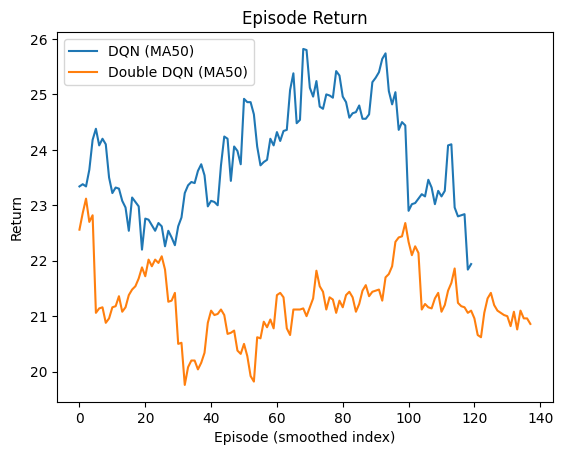

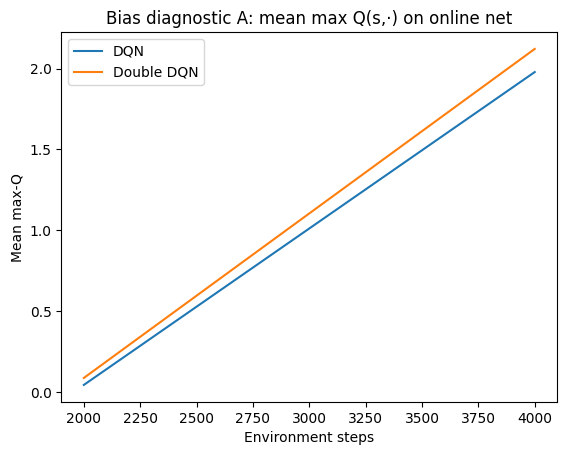

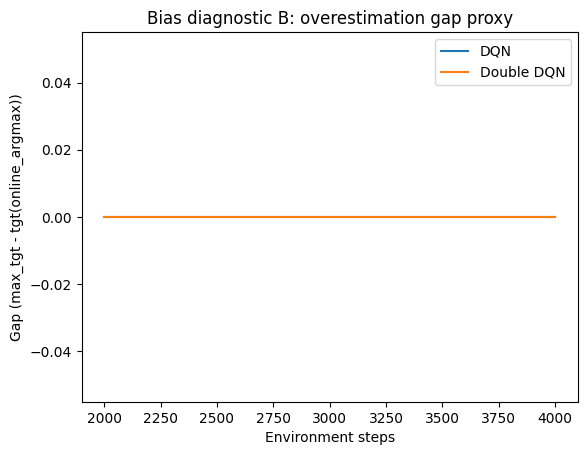

In [ ]:
def plot_results(run_a, run_b, ma_window=50):
    plt.figure()
    plt.title("Episode Return")
    plt.plot(moving_average(run_a["episode_returns"], ma_window), label=f'{run_a["name"]} (MA{ma_window})')
    plt.plot(moving_average(run_b["episode_returns"], ma_window), label=f'{run_b["name"]} (MA{ma_window})')
    plt.xlabel("Episode (smoothed index)")
    plt.ylabel("Return")
    plt.legend()
    plt.show()

    plt.figure()
    plt.title("Bias diagnostic A: mean max Q(s,·) on online net")
    plt.plot(run_a["bias_steps"], run_a["mean_maxQ"], label=run_a["name"])
    plt.plot(run_b["bias_steps"], run_b["mean_maxQ"], label=run_b["name"])
    plt.xlabel("Environment steps")
    plt.ylabel("Mean max-Q")
    plt.legend()
    plt.show()

    plt.figure()
    plt.title("Bias diagnostic B: overestimation gap proxy")
    plt.plot(run_a["bias_steps"], run_a["gap"], label=run_a["name"])
    plt.plot(run_b["bias_steps"], run_b["gap"], label=run_b["name"])
    plt.xlabel("Environment steps")
    plt.ylabel("Gap (max_tgt - tgt(online_argmax))")
    plt.legend()
    plt.show()

plot_results(dqn, ddqn, ma_window=50)


In [ ]:
@torch.no_grad()
def evaluate(q_net, n_episodes=10, seed=123):
    env = make_env(seed=seed, render_mode=None)
    returns = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        done = False
        total = 0.0
        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            a = int(torch.argmax(q_net(obs_t), dim=1).item())
            obs, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            total += r
        returns.append(total)
    env.close()
    return float(np.mean(returns)), float(np.std(returns))

mean_dqn, std_dqn = evaluate(dqn["q_online"], n_episodes=20)
mean_ddqn, std_ddqn = evaluate(ddqn["q_online"], n_episodes=20)

print("DQN   eval:", mean_dqn, "+/-", std_dqn)
print("DDQN  eval:", mean_ddqn, "+/-", std_ddqn)


DQN   eval: 24.45 +/- 23.76652056991094
DDQN  eval: 105.7 +/- 2.7404379212089442


In [ ]:
def render_gif(q_net, path="cartpole.gif", seed=999, max_steps=500):
    env = make_env(seed=seed, render_mode="rgb_array")
    frames = []
    obs, info = env.reset(seed=seed)
    done = False
    steps = 0
    while not done and steps < max_steps:
        frames.append(env.render())
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a = int(torch.argmax(q_net(obs_t), dim=1).item())
        obs, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated
        steps += 1
    env.close()
    imageio.mimsave(path, frames, fps=30)
    return path

gif1 = render_gif(dqn["q_online"], path="dqn_cartpole.gif")
gif2 = render_gif(ddqn["q_online"], path="ddqn_cartpole.gif")

print("Saved:", gif1, gif2)


Saved: dqn_cartpole.gif ddqn_cartpole.gif


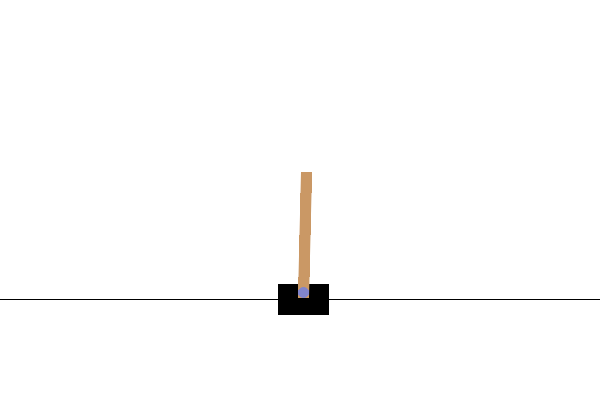

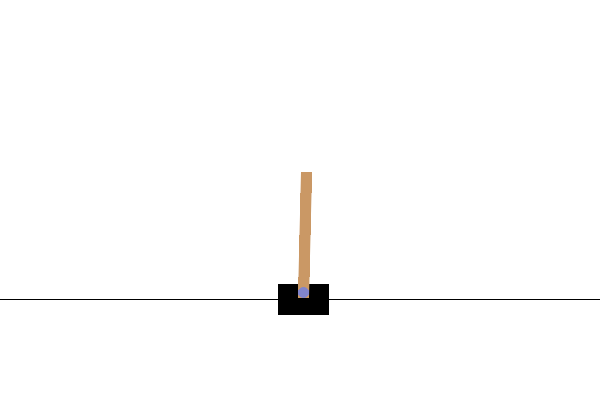

In [ ]:
from IPython.display import Image, display
display(Image(filename="dqn_cartpole.gif"))
display(Image(filename="ddqn_cartpole.gif"))